In [2]:
from google.colab import files
uploaded = files.upload()

Saving online_retail_II.xlsx to online_retail_II.xlsx


In [3]:
import pandas as pd

# Load dataset
df = pd.read_excel("online_retail_II.xlsx")

# View first 5 rows
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
#basic dataset info
print(df.shape)        # rows, columns
print('-'*50)
print(df.columns)      # column names
print('-'*50)
print(df.info())       # data types + nulls

(525461, 8)
--------------------------------------------------
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB
None


In [5]:
#Checking missing values
print(df.isnull().sum())

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [6]:
#Statistical Summary
print(df.describe())

            Quantity                    InvoiceDate          Price  \
count  525461.000000                         525461  525461.000000   
mean       10.337667  2010-06-28 11:37:36.845017856       4.688834   
min     -9600.000000            2009-12-01 07:45:00  -53594.360000   
25%         1.000000            2010-03-21 12:20:00       1.250000   
50%         3.000000            2010-07-06 09:51:00       2.100000   
75%        10.000000            2010-10-15 12:45:00       4.210000   
max     19152.000000            2010-12-09 20:01:00   25111.090000   
std       107.424110                            NaN     146.126914   

         Customer ID  
count  417534.000000  
mean    15360.645478  
min     12346.000000  
25%     13983.000000  
50%     15311.000000  
75%     16799.000000  
max     18287.000000  
std      1680.811316  


In [7]:
#Checking Unique Customers
print("Unique Customers:", df['Customer ID'].nunique())

Unique Customers: 4383


In [8]:
#Checking invalid or negative values
# Negative quantities (returns)
print("Negative Quantity Count:", (df['Quantity'] < 0).sum())

# Zero or negative prices
print("Zero/Negative Price Count:", (df['Price'] <= 0).sum())

Negative Quantity Count: 12326
Zero/Negative Price Count: 3690


In [9]:
#converting date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

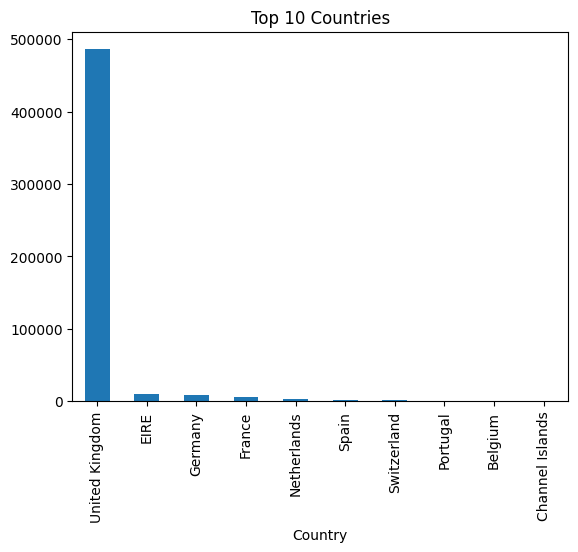

In [10]:
#Initial visualisation to help understand basic behaviour

#top 10 countries with the highest number of purchases.
import matplotlib.pyplot as plt

df['Country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.show()

/tmp/ipykernel_13074/3190949839.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('InvoiceDate').resample('M').size().plot()


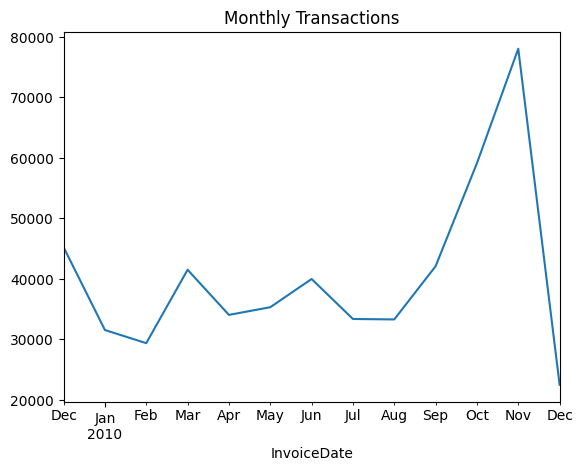

In [11]:
#Transactions over time
df.set_index('InvoiceDate').resample('M').size().plot()
plt.title("Monthly Transactions")
plt.show()

** **

**Key Observations after data observation basic visualisation -**

1. Dataset contains around 500K transactions
2. Missing CustomerID values exist
1. Negative quantities indicate product returns
2. UK dominates transactions (if typical dataset)
1. Data is transactional, not customer-level  


*   Clean understanding of dataset
*   Identified issues
*   Basic visualization

**STEP 2: Data Cleaning & Preprocessing**



1. Handle missing values
2. Remove invalid transactions
1. Fix data types
2. clean dataset for customer-level analysis


In [12]:
#Removing missing customer ids
df = df.dropna(subset=['Customer ID'])

In [13]:
#converting customer ids to integer
df['Customer ID'] = df['Customer ID'].astype(int)

In [14]:
#removing negative and invalid values

#remove cancelled/returned orders
df = df[df['Quantity'] > 0]

#Remove invalid prices
df = df[df['Price'] > 0]

In [15]:
#remove duplicates
df = df.drop_duplicates()

In [16]:
df['TotalAmount'] = df['Quantity'] * df['Price'] #feature engineering

#converting date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']) #data preprocessing

#create reference date for recency
import datetime as dt

reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

In [17]:
#checking clean dataset
print(df.info())
print('_'*100)
print()
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 400916 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      400916 non-null  object        
 1   StockCode    400916 non-null  object        
 2   Description  400916 non-null  object        
 3   Quantity     400916 non-null  int64         
 4   InvoiceDate  400916 non-null  datetime64[ns]
 5   Price        400916 non-null  float64       
 6   Customer ID  400916 non-null  int64         
 7   Country      400916 non-null  object        
 8   TotalAmount  400916 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 30.6+ MB
None
____________________________________________________________________________________________________

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    793

**Data Aggregation → Customer-Level Data**

Now we convert transaction data into customer-level features, which is crucial.

We will compute:

1.   Recency(R)
2.   Frequency(F)
1.   Monetary(M)





In [18]:
#1. Recency (How recently customer purchased)
recency = df.groupby('Customer ID')['InvoiceDate'].max().reset_index()

recency['Recency'] = (reference_date - recency['InvoiceDate']).dt.days

recency = recency[['Customer ID', 'Recency']]

In [19]:
#2. Frequency (How often customer buys)
frequency = df.groupby('Customer ID')['Invoice'].nunique().reset_index()
frequency.columns = ['Customer ID', 'Frequency']

In [20]:
#3. Monetary (How much customer spends)
monetary = df.groupby('Customer ID')['TotalAmount'].sum().reset_index()
monetary.columns = ['Customer ID', 'Monetary']

In [21]:
#4. Merging rfm data
rfm = recency.merge(frequency, on='Customer ID')
rfm = rfm.merge(monetary, on='Customer ID')

print(rfm.head())

   Customer ID  Recency  Frequency  Monetary
0        12346      165         11    372.86
1        12347        3          2   1323.32
2        12348       74          1    222.16
3        12349       43          3   2671.14
4        12351       11          1    300.93


In [22]:
#Handle Skewed Data (IMPORTANT for Clustering)
#Customer data is usually skewed, so we apply log transformation:

import numpy as np

rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

In [23]:
#Normalize Data (Important for K-Means)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[['Recency', 'Frequency', 'Monetary']])

In [24]:
#Final Dataset for ML
rfm_final = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
print(rfm_final.head())

    Recency  Frequency  Monetary
0  0.966262   1.613017 -0.534787
1 -1.900165  -0.394693  0.452542
2  0.355000  -0.981910 -0.937590
3 -0.055302   0.021945  1.000535
4 -1.054928  -0.981910 -0.701598


**What we did in step 2-**
*   Cleaned dataset (no nulls, no invalid entries)
*   Converted transactions → customer-level data
*   Created RFM features (core of customer segmentation)
*   Normalized data (ready for clustering)

**Important Report Points**
1. Missing values were removed to ensure data integrity
2. Negative values (returns) and invalid entries were filtered out
1. New feature TotalAmount was created to capture customer spending
2. RFM model (Recency, Frequency, Monetary) was used to convert transactional data into customer-level data
1. Log transformation was applied to reduce skewness
2. Standardization was performed to ensure all features contribute equally to clustering



---



**STEP 3: Exploratory Data Analysis (EDA) + Feature Understanding**

We will:
1.   Understand customer behavior patterns
2.   Analyze RFM features visually
1.   Detect outliers & skewness
2.   Build intuition for segmentation

In [25]:
#using rfm dataset
rfm

,Customer ID,Recency,Frequency,Monetary
0,12346,165,11,372.86
1,12347,3,2,1323.32
2,12348,74,1,222.16
3,12349,43,3,2671.14
4,12351,11,1,300.93
...,...,...,...,...
4307,18283,18,6,619.37
4308,18284,67,1,461.68
4309,18285,296,1,427.00
4310,18286,112,2,1296.43


In [26]:
#basic statistics
print(rfm.describe())

        Customer ID      Recency    Frequency       Monetary
count   4312.000000  4312.000000  4312.000000    4312.000000
mean   15349.290353    91.171846     4.455705    2040.406712
std     1701.200176    96.860633     8.170213    8911.755977
min    12346.000000     1.000000     1.000000       2.950000
25%    13882.500000    18.000000     1.000000     307.187500
50%    15350.500000    53.000000     2.000000     701.615000
75%    16834.250000   136.000000     5.000000    1714.932500
max    18287.000000   374.000000   205.000000  349164.350000


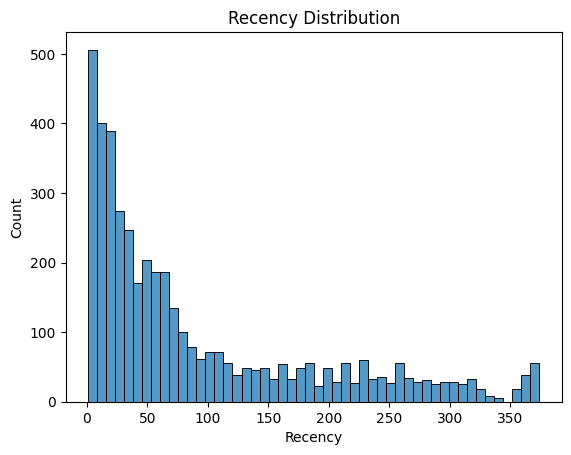

In [27]:
#distribution plots

#1. recency distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(rfm['Recency'], bins=50)
plt.title("Recency Distribution")
plt.show()

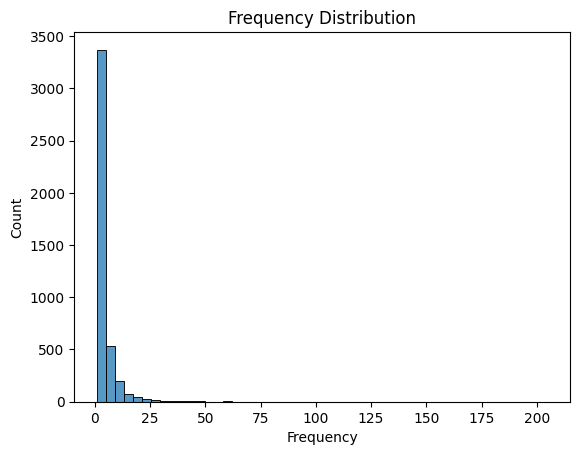

In [28]:
#2. Frequency Distribution
sns.histplot(rfm['Frequency'], bins=50)
plt.title("Frequency Distribution")
plt.show()

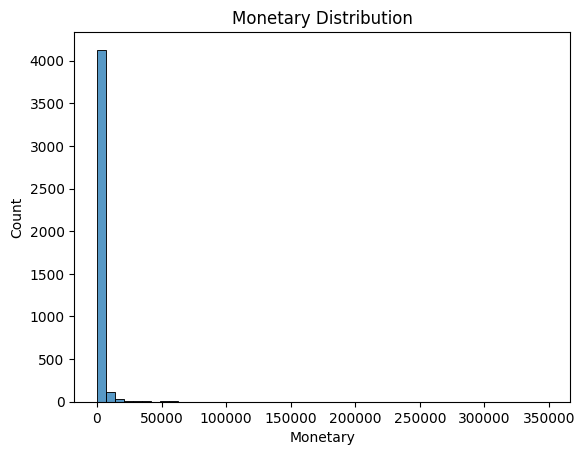

In [29]:
#3. Monetary Distribution
sns.histplot(rfm['Monetary'], bins=50)
plt.title("Monetary Distribution")
plt.show()

In [ ]:
#Most customers: Buy rarely ; Spend small amounts
#Few customers:Buy frequently ; Spend a lot

#skewed distribution

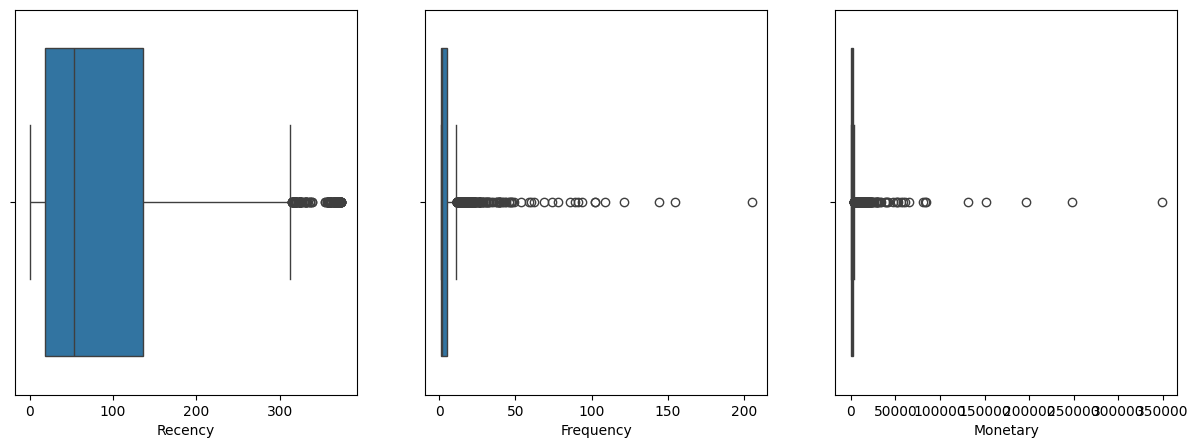

In [30]:
#Boxplots (to detect outliers)
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(x=rfm['Recency'])

plt.subplot(1,3,2)
sns.boxplot(x=rfm['Frequency'])

plt.subplot(1,3,3)
sns.boxplot(x=rfm['Monetary'])

plt.show()
#Extreme outliers (especially in Monetary & Frequency)

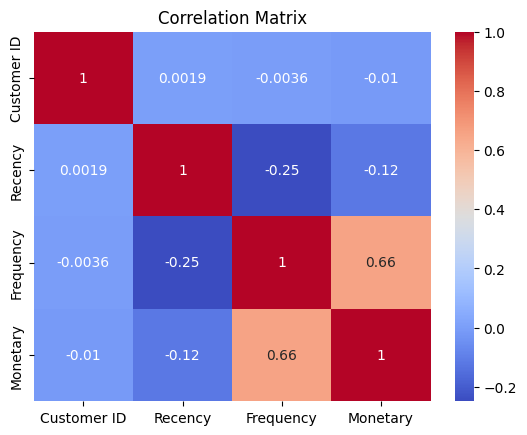

In [31]:
#Correlation Analysis
sns.heatmap(rfm.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#Frequency ↑ → Monetary ↑ (usually positive correlation)
#Recency ↓ → Frequency ↑ (active customers buy more)

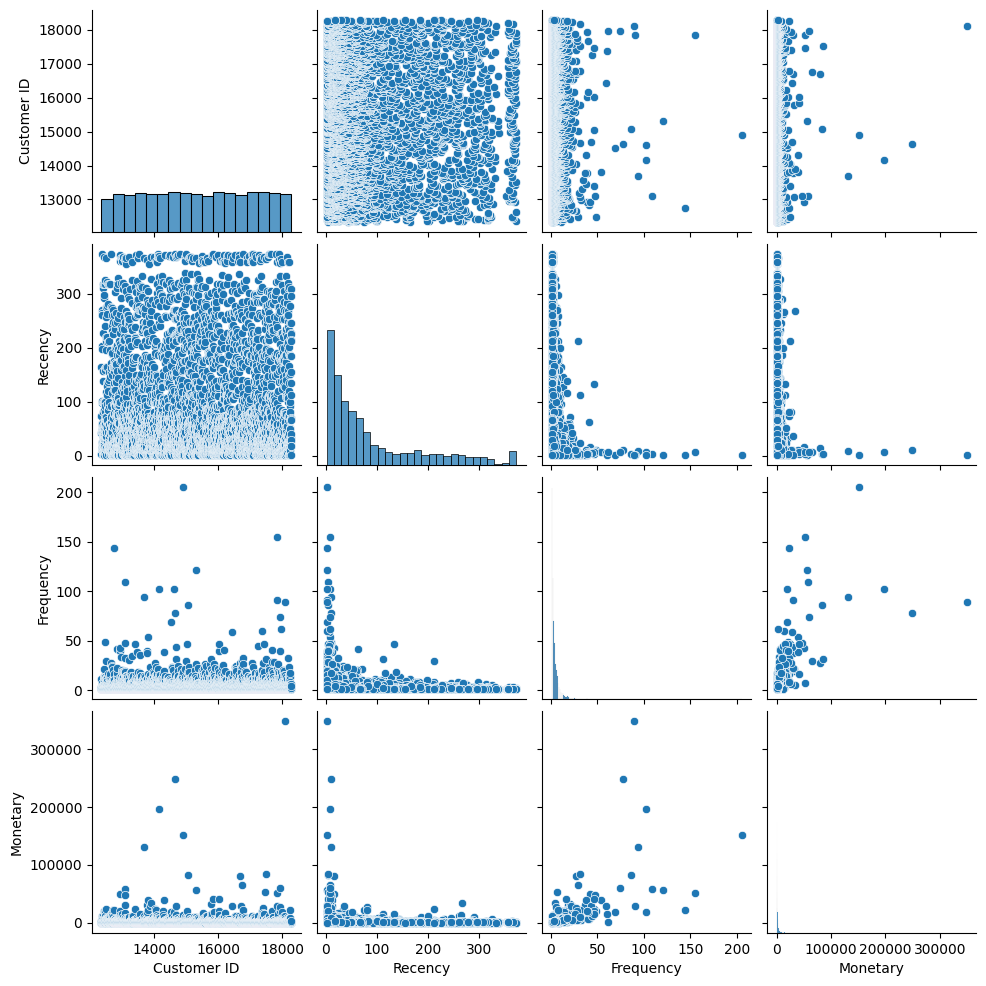

In [32]:
#Pairplot
sns.pairplot(rfm)
plt.show()

#Relationship between features
#Possible natural clusters forming



1.   Understood customer behavior
2.   Identified skewness & outliers
1.   Validated need for scaling (done in Step 2)
2.   Built foundation for clustering


---



**STEP 4: K-Means Clustering + Elbow Method + Silhouette Score**



1.  Apply K-Means clustering
2.  Find optimal number of clusters (K) using: a. Elbow Method b. Silhouette Score
1.   Assign cluster labels to customers

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [34]:
#use scaled data
rfm_final

,Recency,Frequency,Monetary
0,0.966262,1.613017,-0.534787
1,-1.900165,-0.394693,0.452542
2,0.355000,-0.981910,-0.937590
3,-0.055302,0.021945,1.000535
4,-1.054928,-0.981910,-0.701598
...,...,...,...
4307,-0.701379,0.832412,-0.139445
4308,0.279617,-0.981910,-0.368391
4309,1.413837,-0.981910,-0.429212
4310,0.670364,-0.394693,0.436529


In [35]:
#Elbow Method (Find Optimal K)

#WCSS (Within Cluster Sum of Squares)
wcss = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_final)
    wcss.append(kmeans.inertia_)

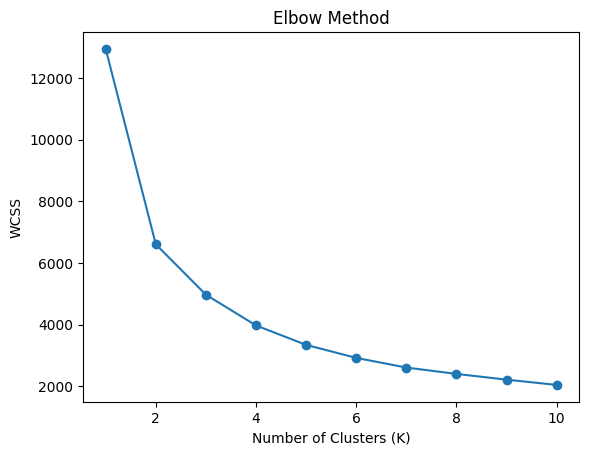

In [36]:
import matplotlib.pyplot as plt

plt.plot(K_range, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

#point where curve bends sharply = optimal K

In [37]:
#Silhouette Score (Validate K)
#Measures how well-separated clusters are.
#Range: -1 to +1
#Closer to 1 = better clustering

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_final)

    score = silhouette_score(rfm_final, labels)
    print(f"K = {k}, Silhouette Score = {score}")

K = 2, Silhouette Score = 0.4217866227593967
K = 3, Silhouette Score = 0.32713782478145986
K = 4, Silhouette Score = 0.33289807834480833
K = 5, Silhouette Score = 0.3196411260030095
K = 6, Silhouette Score = 0.30380407510564783
K = 7, Silhouette Score = 0.30483533865043383
K = 8, Silhouette Score = 0.28958018692896575
K = 9, Silhouette Score = 0.29228622023063017
K = 10, Silhouette Score = 0.28199439132653253


In [38]:
#Apply Final K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_final)

In [39]:
#Check Cluster Distribution
print(rfm['Cluster'].value_counts())

Cluster
2    1779
1    1701
0     832
Name: count, dtype: int64


In [40]:
#Cluster Centers
cluster_summary = rfm.groupby('Cluster').mean()
print(cluster_summary)

          Customer ID     Recency  Frequency     Monetary
Cluster                                                  
0        15318.659856   18.152644  13.252404  7212.056500
1        15401.223398  164.288066   1.295708   313.878955
2        15313.959528   55.410905   3.363125  1272.565843


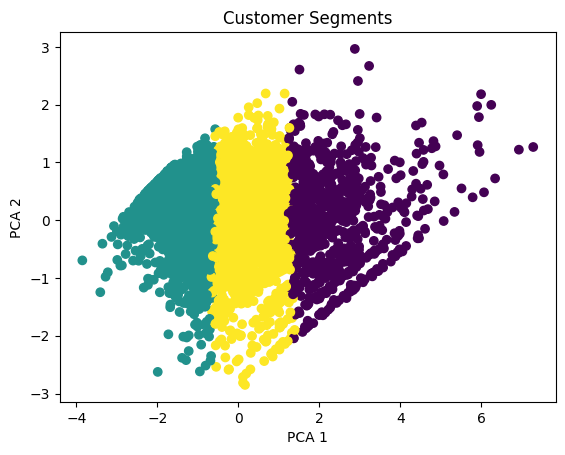

In [41]:
#Visualization (2D Projection)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_final)

plt.scatter(rfm_pca[:,0], rfm_pca[:,1], c=rfm['Cluster'])
plt.title("Customer Segments")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

**STEP 4 OUTCOMES**
1.   Found optimal number of clusters
2.   Segmented customers using K-Means
1.   Visualized clusters
2.   Prepared for interpretation


K-Means clustering was applied to the scaled RFM dataset to segment customers into distinct groups. The optimal number of clusters was determined using the Elbow Method and Silhouette Score, ensuring both statistical validity and interpretability. The resulting clusters represent groups of customers with similar purchasing behavior.



---



**STEP 5: Psychographic Feature Engineering + Cluster Labeling**

1.   Create psychographic features from RFM
2.   Add them to dataset
1.   Interpret clusters deeply
2.   Assign human-readable labels like:
*   Luxury Seekers
*   Budget Buyers
*   Impulse Shoppers
*   Loyal Customers

In [42]:
#Create Psychographic Features

#1. Impulsiveness: Frequent purchases in short time
rfm['Impulsiveness'] = rfm['Frequency'] / (rfm['Recency'] + 1)

#✔ High value = buys often & recently
#✔ Low value = inactive or occasional buyer

In [43]:
#2. Budget Sensitivity
rfm['BudgetSensitivity'] = 1 / (rfm['Monetary'] + 1)

#✔ High value = low spender (budget-conscious)
#✔ Low value = high spender

In [44]:
#3. Loyalty Score - Combination of frequency & recency
rfm['LoyaltyScore'] = rfm['Frequency'] / (rfm['Recency'] + 1)

In [45]:
#4.Spending Power
rfm['SpendingPower'] = rfm['Monetary']

In [46]:
#5. Engagement Score
rfm['EngagementScore'] = (rfm['Frequency'] + rfm['Monetary']) / (rfm['Recency'] + 1)

In [47]:
#Normalize these features
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

psych_features = ['Impulsiveness', 'BudgetSensitivity', 'LoyaltyScore', 'SpendingPower', 'EngagementScore']

rfm[psych_features] = scaler.fit_transform(rfm[psych_features])

In [48]:
#Analyze Clusters with Psychographic Features
cluster_psych = rfm.groupby('Cluster')[psych_features].mean()
print(cluster_psych)

         Impulsiveness  BudgetSensitivity  LoyaltyScore  SpendingPower  \
Cluster                                                                  
0             0.022523           0.001319      0.022523       0.020647   
1             0.000123           0.023875      0.000123       0.000891   
2             0.001301           0.005054      0.001301       0.003636   

         EngagementScore  
Cluster                   
0               0.007350  
1               0.000019  
2               0.000250  


In [49]:
#assign labels
def label_customer(row):
    if row['Monetary'] > 1000 and row['Frequency'] > 5:
        return "Luxury Seeker"
    elif row['BudgetSensitivity'] > 0.7:
        return "Budget Buyer"
    elif row['Impulsiveness'] > 0.5:
        return "Impulse Shopper"
    else:
        return "Regular Customer"

rfm['Segment'] = rfm.apply(label_customer, axis=1)

In [50]:
#Check Final Segments
print(rfm['Segment'].value_counts())

Segment
Regular Customer    3414
Luxury Seeker        896
Budget Buyer           2
Name: count, dtype: int64


Psychographic features such as impulsiveness, budget sensitivity, loyalty, and engagement were derived from behavioral data (RFM). These features enabled deeper interpretation of customer behavior beyond numerical clustering. Based on these insights, clusters were labeled into meaningful segments such as Luxury Seekers, Budget Buyers, and Impulse Shoppers, making the model interpretable and actionable for business decision-making.

**What we did in previous step**
1.   Converted behavior → psychology
2.   Made clusters interpretable
1.   Created real-world usable segments



---







**STEP 6: Build Streamlit App (User Input → Segment → Recommendation)**

1.   User enters customer details
2.   Model predicts segment
1.   System explains why
2.   Gives business recommendations

In [51]:
# FINAL TRAINING + SAVING

import pickle
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Use RFM data
X = rfm[['Recency', 'Frequency', 'Monetary']]

# Log transform
X_log = np.log1p(X)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Train model
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

# Save files
pickle.dump(kmeans, open('kmeans_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

print("✅ Model and scaler saved!")

✅ Model and scaler saved!


In [52]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 114.9 MB/s eta 0:00:00


In [53]:
%%writefile app.py
import streamlit as st
import numpy as np
import pickle
import matplotlib.pyplot as plt


# Page config
st.set_page_config(page_title="Customer Segmentation Dashboard", layout="wide")


# Load model
model = pickle.load(open('kmeans_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))


# Title
st.markdown("<h1 style='text-align:center;'>📊 Customer Segmentation & Analysis</h1>", unsafe_allow_html=True)
st.markdown("---")


# Layout: 3 columns
col1, col2, col3 = st.columns([1, 2, 1])


# ---------------- LEFT PANEL (INPUTS) ----------------
with col1:
   st.subheader("📥 Customer Input")


   recency = st.slider("Recency (days)", 0, 365, 30)
   frequency = st.slider("Frequency", 0, 50, 5)
   monetary = st.slider("Monetary (₹)", 0, 100000, 5000)


   predict = st.button("🚀 Predict", use_container_width=True)


# ---------------- CENTER PANEL (GRAPH + RESULT) ----------------
with col2:
   st.subheader("📈 Customer Behavior Graph")


   # Dummy graph (based on inputs)
   days = [10, 20, 30]
   values = [frequency*2, frequency*3, frequency*4]


   fig, ax = plt.subplots()
   ax.plot(days, values, marker='o')
   ax.set_xlabel("Time")
   ax.set_ylabel("Engagement Level")
   ax.set_title("Customer Activity Trend")


   st.pyplot(fig)


   if predict:


       input_data = np.array([[recency, frequency, monetary]])
       input_data = np.log1p(input_data)
       input_scaled = scaler.transform(input_data)


       cluster = int(model.predict(input_scaled)[0])


       def get_segment(cluster):
           mapping = {
               0: "Luxury Seeker 💎",
               1: "Budget Buyer 🛒",
               2: "Impulse Shopper ⚡"
           }
           return mapping.get(cluster, "Regular Customer 👤")


       segment = get_segment(cluster)


       st.markdown("### 🎯 Prediction Result")
       st.success(f"{segment}")


       st.metric("Cluster ID", cluster)


# ---------------- RIGHT PANEL (EXPLANATION) ----------------
with col3:
   st.subheader("📄 Insights & Explanation")


   st.write("""
   This dashboard analyzes customer behavior using:

   • **Recency** – How recently the customer purchased
   • **Frequency** – How often they purchase
   • **Monetary** – How much they spend

   Based on these, customers are grouped using **K-Means clustering**.
   """)


   if predict:
       st.markdown("### 🧠 Interpretation")


       st.write(f"""
       - Recency: {recency} days
       - Frequency: {frequency} purchases
       - Monetary: ₹{monetary}


       This customer is categorized as **{segment}**.
       """)


       st.markdown("### 💡 Business Strategy")


       if "Luxury" in segment:
           st.success("Focus on premium services and exclusive deals.")
       elif "Budget" in segment:
           st.success("Provide discounts and value offers.")
       elif "Impulse" in segment:
           st.success("Use urgency-based marketing like flash sales.")
       else:
           st.success("Maintain engagement with regular communication.")


# ---------------- BOTTOM SECTION ----------------
st.markdown("---")
st.subheader("📊 Summary Dashboard")


colA, colB, colC = st.columns(3)


colA.metric("Recency", f"{recency} days")
colB.metric("Frequency", frequency)
colC.metric("Monetary", f"₹{monetary}")


st.markdown("""
---
💡 **About Project:**
This system uses machine learning to segment customers based on behavioral patterns, helping businesses make smarter marketing decisions.
""")

Writing app.py


In [54]:
pip install streamlit pyngrok

In [55]:
!streamlit run app.py &>/content/logs.txt &

In [56]:
from pyngrok import ngrok

ngrok.set_auth_token("2mNKpb8UBYqigox2lO6Bch6vFRs_4pZ9MGkVXwzjBq1DL8KvE")

In [57]:
public_url = ngrok.connect(8501)
public_url


<NgrokTunnel: "https://3baf-34-90-212-97.ngrok-free.app" -> "http://localhost:8501">

In [58]:
import os
os.listdir()

['.config',
 'logs.txt',
 'scaler.pkl',
 'online_retail_II.xlsx',
 'kmeans_model.pkl',
 'app.py',
 'sample_data']